# Part B2 — QLoRA fine-tuning with Adapter B

Fine-tunes `mistralai/Mistral-7B-v0.1` (4-bit NF4 base) with **Adapter B** (r=16, alpha=32, `q_proj` and `v_proj`) on the 40 training pairs from B1, using `transformers`, `peft` and `bitsandbytes`. All logic is in `src/qlora_train.py`; this notebook calls it and shows the results. Mistral-7B-v0.1 is a base model with no chat template, so the SFT format is the `### Instruction` / `### Response` block used for the Part A baseline.

In [1]:
# Dependencies come from requirements.txt, the single source of truth for every notebook in this repo.
from pathlib import Path
ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "qlora_train.py").is_file():
    ROOT = ROOT.parent
%pip install -q -r {ROOT}/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, json
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
import qlora_train as q

pd.set_option("display.width", 200, "display.max_colwidth", 120)
design = q.check_design()
print({k: v for k, v in design.items() if k != "hyperparameters"})

{'design_check_passed': True, 'model_id': 'mistralai/Mistral-7B-v0.1', 'train_examples': 40, 'eval_examples': 10, 'max_tokens': 239, 'mean_tokens': 173.7, 'pad_token': '<unk>', 'eos_token': '</s>', 'optimizer_steps': 30, 'response_tokens_in_loss_train': 5338}


## Training text and loss masking

Each example is `BOS + ### Instruction … ### Response:\n + answer + </s>`. The prompt tokens get label `-100`, so the loss is computed on the answer and the end-of-sequence token only. The pad token is `<unk>` (not EOS), otherwise the collator would mask the EOS label and the adapter would never learn to stop.

In [3]:
tok = q.load_tokenizer()
row = q.read_jsonl(q.TRAIN_PATH)[0]
ex = q.build_example(tok, row["instruction"], row["response"])
n_prompt = sum(1 for x in ex["labels"] if x == -100)
print("tokens:", len(ex["input_ids"]), "| masked prompt tokens:", n_prompt, "| tokens in the loss:", len(ex["input_ids"]) - n_prompt)
print("MASKED  :", repr(tok.decode(ex["input_ids"][:n_prompt])))
print("IN LOSS :", repr(tok.decode(ex["input_ids"][n_prompt:])))

tokens: 155 | masked prompt tokens: 40 | tokens in the loss: 115
MASKED  : '<s> ### Instruction:\nHow should primaquine be dosed to prevent relapse in uncomplicated P. vivax or P. ovale malaria?\n\n### Response:\n'
IN LOSS : 'Per WHO malaria guidelines, relapse prevention uses a high total primaquine dose of 7 mg/kg, delivered as 0.5 mg/kg daily over 14 days or as 1 mg/kg daily over 7 days. The 7-day schedule is reserved for patients with at least 70% G6PD activity, and G6PD status must be tested first, with pregnant women and infants under 1 month excluded. This output is for educational/reference purposes only and must not replace professional clinical judgment.</s>'


## Hyperparameters

The brief asks for batch size, learning rate, epochs or steps, and maximum sequence length. They are all in this table (the max sequence length of 256 comes from the B1 token report: longest example 239 tokens).

In [4]:
hp = pd.Series(q.HYPERPARAMS, name="value")
hp["optimizer_steps_total"] = design["optimizer_steps"]
print(hp.to_string())

adapter                                                                                      B
lora_r                                                                                      16
lora_alpha                                                                                  32
lora_dropout                                                                              0.05
target_modules                                                                [q_proj, v_proj]
quantization                                  4-bit NF4, double quantization, bfloat16 compute
epochs                                                                                       3
per_device_batch_size                                                                        1
gradient_accumulation_steps                                                                  4
effective_batch_size                                                                         4
learning_rate                                     

## Train (GPU)

This cell loads the base model in 4-bit, measures the eval loss of the untuned model, trains for 3 epochs, saves the adapter and runs a smoke generation.

In [5]:
report = q.run_training()
print(json.dumps({k: v for k, v in report.items() if k not in ("smoke_generate", "hyperparameters", "inputs_sha256")}, indent=2))

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss


{
  "model_id": "mistralai/Mistral-7B-v0.1",
  "train_examples": 40,
  "eval_examples": 10,
  "optimizer_steps": 30,
  "trainable_parameters": 6815744,
  "total_parameters": 7248547840,
  "trainable_percent": 0.094,
  "eval_loss_before_training": 2.1270833015441895,
  "eval_loss_by_epoch": [
    {
      "epoch": 1.0,
      "step": 10,
      "eval_loss": 1.5038957595825195
    },
    {
      "epoch": 2.0,
      "step": 20,
      "eval_loss": 1.4249526262283325
    },
    {
      "epoch": 3.0,
      "step": 30,
      "eval_loss": 1.426715612411499
    }
  ],
  "final_train_loss_logged": 1.0829,
  "mean_train_loss": 1.3556561787923178,
  "train_seconds": 45.5,
  "base_model_gpu_gb": 4.13,
  "peak_gpu_memory_gb": 5.25,
  "gpu": "NVIDIA RTX A6000",
  "versions": {
    "torch": "2.8.0+cu128",
    "transformers": "4.46.3",
    "peft": "0.13.2",
    "python": "3.12.3"
  },
  "bitsandbytes": "0.50.2",
  "adapter_dir": "adapters/adapter_b",
  "adapter_files": [
    "README.md",
    "adapter_conf

In [6]:
print(f"Trainable parameters: {report['trainable_parameters']:,} of {report['total_parameters']:,} ({report['trainable_percent']}%)")
print(f"4-bit base model on the GPU: {report['base_model_gpu_gb']} GB")
print(f"Optimizer steps: {report['optimizer_steps']} | train time: {report['train_seconds']} s | peak GPU memory: {report['peak_gpu_memory_gb']} GB on {report['gpu']}")
print(f"Versions: {report['versions']}, bitsandbytes {report['bitsandbytes']}")
loss = pd.read_csv(q.LOSS_PATH)
print(loss.to_string(index=False, formatters={"loss": "{:.4f}".format, "grad_norm": "{:.2f}".format, "learning_rate": "{:.2e}".format}))

Trainable parameters: 6,815,744 of 7,248,547,840 (0.094%)
4-bit base model on the GPU: 4.13 GB
Optimizer steps: 30 | train time: 45.5 s | peak GPU memory: 5.25 GB on NVIDIA RTX A6000
Versions: {'torch': '2.8.0+cu128', 'transformers': '4.46.3', 'peft': '0.13.2', 'python': '3.12.3'}, bitsandbytes 0.50.2
 step  epoch   loss learning_rate grad_norm
    1    0.1 2.0986      2.00e-04      8.06
    2    0.2 2.2694      1.93e-04     10.99
    3    0.3 1.8469      1.86e-04      9.76
    4    0.4 1.8298      1.79e-04      8.86
    5    0.5 1.9895      1.72e-04      9.01
    6    0.6 2.0367      1.66e-04     12.35
    7    0.7 1.6481      1.59e-04     11.16
    8    0.8 1.4449      1.52e-04     12.41
    9    0.9 1.0675      1.45e-04     10.81
   10    1.0 1.5375      1.38e-04     17.92
   11    1.1 1.3626      1.31e-04     12.05
   12    1.2 1.3541      1.24e-04     12.34
   13    1.3 1.2117      1.17e-04     10.56
   14    1.4 1.3191      1.10e-04     10.66
   15    1.5 1.1200      1.03e-04    

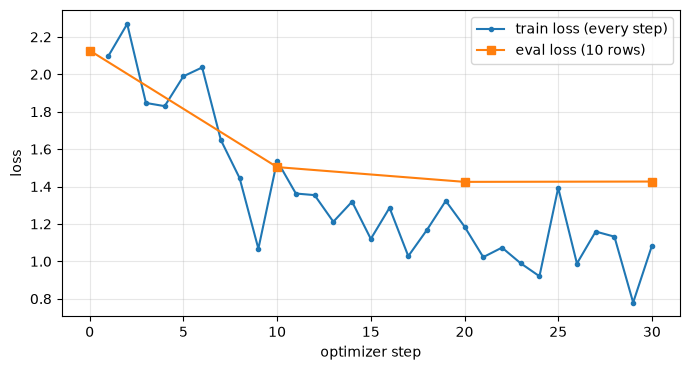

eval loss before training (4-bit base): 2.1271
 epoch  step  eval_loss
   1.0    10     1.5039
   2.0    20     1.4250
   3.0    30     1.4267


In [7]:
import matplotlib.pyplot as plt

ev = pd.DataFrame(report["eval_loss_by_epoch"])
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(loss["step"], loss["loss"], marker="o", ms=3, label="train loss (every step)")
ax.plot([0] + list(ev["step"]), [report["eval_loss_before_training"]] + list(ev["eval_loss"]), marker="s", label="eval loss (10 rows)")
ax.set_xlabel("optimizer step"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("eval loss before training (4-bit base):", round(report["eval_loss_before_training"], 4))
print(ev.round(4).to_string(index=False))

## Smoke generation

Greedy, `max_new_tokens=150`, one training instruction and one unseen eval instruction. The three Part A prompts are kept for B3 and are not used here.

In [8]:
for s in report["smoke_generate"]:
    print(f"[{s['split']} {s['id']}] new_tokens={s['new_tokens']} stopped_on_eos={s['stopped_on_eos']} ends_with_disclaimer={s['ends_with_disclaimer']}")
    print("INSTRUCTION:", s["instruction"])
    print("OUTPUT     :", s["output"])
    print()

[train p01] new_tokens=90 stopped_on_eos=True ends_with_disclaimer=True
INSTRUCTION: How should primaquine be dosed to prevent relapse in uncomplicated P. vivax or P. ovale malaria?
OUTPUT     : Per WHO malaria guidelines, a single 0.25 mg/kg dose is given on day 1, followed by 0.15 mg/kg daily for 12 days, with a minimum of 7 days in areas with low G6PD deficiency prevalence and 14 days in areas with high prevalence. This output is for educational/reference purposes only and must not replace professional clinical judgment.

[eval p05] new_tokens=121 stopped_on_eos=True ends_with_disclaimer=True
INSTRUCTION: How should an antimalarial be dosed in a large or obese adult so that the patient is not under-treated?
OUTPUT     : Per WHO malaria guidelines, the dose of artemisinin-based combination therapy is 4 tablets of artesunate plus 3 tablets of partner drug per adult body weight of 40-59 kg, 5 tablets plus 4 tablets for 60-74 kg, 6 tablets plus 5 tablets for 75-99 kg and 7 tablets plus 

In [9]:
files = sorted((q.ADAPTER_DIR).iterdir())
for f in files:
    print(f"{f.name:32s} {f.stat().st_size / 1e6:8.2f} MB")
print("adapter directory:", q.ADAPTER_DIR.relative_to(ROOT), "(weights are gitignored)")
print("reports:", [p.name for p in sorted(q.REPORTS_DIR.glob("qlora_*"))])

README.md                            0.01 MB
adapter_config.json                  0.00 MB
adapter_model.safetensors           27.28 MB
special_tokens_map.json              0.00 MB
tokenizer.json                       3.51 MB
tokenizer.model                      0.49 MB
tokenizer_config.json                0.00 MB
adapter directory: adapters/adapter_b (weights are gitignored)
reports: ['qlora_design_check.json', 'qlora_loss.csv', 'qlora_smoke.json', 'qlora_training.json']


## Reproducibility check

The same seed, data and code are run a second time into a temporary folder and compared with the first run. GPU kernels are not bit-deterministic, so the check reports how close the two runs are, not whether they are identical.

In [10]:
repro = q.reproducibility_check(report)
print(json.dumps(repro, indent=2))

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss


{
  "eval_loss_before": [
    2.1270833015441895,
    2.1270833015441895
  ],
  "eval_loss_by_epoch_first_run": [
    1.5039,
    1.425,
    1.4267
  ],
  "eval_loss_by_epoch_second_run": [
    1.5035,
    1.4242,
    1.4252
  ],
  "max_abs_eval_loss_difference": 0.00149,
  "smoke_outputs_identical": [
    true,
    true
  ]
}


## Inferences

**What the numbers say.** The eval loss on the 10 held-out rows fell from **2.127** (untuned 4-bit base) to 1.504 after epoch 1, 1.425 after epoch 2 and 1.427 after epoch 3, a drop of about a third (33%). Almost all of it comes in the first epoch. Epoch 3 is 0.002 above epoch 2, which is inside the run-to-run difference shown by the reproducibility check (up to 0.0015), so the eval loss has plateaued while the training loss keeps falling (about 2.1 at step 1, about 1.1 at step 30). With 40 training rows that is the early sign of memorising, so three epochs is the right ceiling and more would not help. Ten eval rows give a noisy estimate, so the size of the drop is more trustworthy than any third decimal.

**What the adapter learned.** The response *shape*. Both smoke outputs open with "Per WHO malaria guidelines", end with the exact disclaimer and stop on their own (90 and 121 new tokens, both below the 150 limit, `stopped_on_eos=True`). The end-of-sequence token and the response-only loss did what they were meant to do.

**What it did not learn.** The *facts*. For training row p01 the adapter gives a primaquine regimen (0.25 mg/kg on day 1, then 0.15 mg/kg for 12 days) that differs from the answer it was trained on (7 mg/kg total, either 0.5 mg/kg for 14 days or 1 mg/kg for 7 days). For the unseen row p05 it invents tablet counts per weight band (4+3, 5+4, 6+5, 7+6) that appear nowhere in the training pair. The per-token loss is still about 1.4, so the model is fluent and confident but not reliable on numbers. Forty pairs teach style and the habit of citing a guideline; they do not add clinical knowledge. B3 therefore has to check numbers and claims against the corpus, not only the format, and it should compare the baseline's invented "Evidence/References" sections with these invented doses as two different kinds of hallucination. This adapter is a study artefact, not something to use for clinical decisions.

**Reproducibility.** A second run with the same seed, data and code gave the same eval loss before training and eval losses within 0.0015 of the first run after each epoch, and both smoke outputs were identical. GPU kernels are not bit-deterministic, so exact equality of every number is not expected; an earlier trial run of the same code did produce a different unseen-prompt output, so B3 text should be read from the saved files and not regenerated from memory.

**Cost.** 6.8 million trainable parameters (0.094% of the 7.25 billion), 30 optimizer steps in 45.5 seconds. The 4-bit base occupies 4.13 GB and training peaks at 5.25 GB on the RTX A6000, so the same recipe fits a 16 GB card.

**Caveats.** (1) The "before" loss is measured on the 4-bit base with an untrained adapter (its B matrices start at zero), not on the bf16 baseline of Part A. (2) The gradient norm was between 8 and 18 on every step and was clipped to 1.0 (`max_grad_norm`); with Adam the update size is largely insensitive to that scaling, and the loss fell steadily. (3) The hyperparameters were fixed before training and were not tuned on the eval rows or the three B3 prompts. (4) The `use_cache` and gradient-checkpointing warnings of the first trial were removed by setting `use_cache=False` for training and `use_reentrant=False` explicitly.